# Лабораторная работа 4: DQN для Breakout

В этом ноутбуке собрано полное решение лабораторной работы: подготовка среды `Breakout`, реализация `DQN` для Atari, обучение нескольких конфигураций, визуализация обучения, анализ оценок состояний и показ видео с лучшей моделью.

За основу по общей логике взят практический ноутбук `AdvancedML_Practice_9_(RL_DQN).ipynb`, но итоговая реализация полностью переработана под пиксельные наблюдения Atari: добавлены препроцессинг кадров, стек из 4 кадров, сверточная сеть, replay buffer для изображений и отдельная логика оценки модели.

Лучший результат в этой версии ноутбука достигается конфигурацией `preprocessing_strong_from_scratch`: модель стабильно показывает результат порядка `34` очков за эпизод, что превышает ориентир из условия лабораторной и уже можно считать успешным решением задачи.

## 1. Подготовка окружения

Импортируем библиотеки, настраиваем устройство и проверяем доступность Atari окружения.


In [43]:
import os
import sys
import json
import time
import math
import base64
import random
from dataclasses import dataclass, asdict, replace
from pathlib import Path
from collections import deque, defaultdict

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    get_ipython().run_line_magic('pip', "install -q 'gymnasium[atari]' ale-py autorom imageio[ffmpeg] pillow tqdm")

import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import imageio.v2 as imageio
from tqdm.auto import tqdm
from IPython.display import HTML, Video, display

try:
    import ale_py
    gym.register_envs(ale_py)
    ALE_AVAILABLE = True
except Exception as exc:
    ALE_AVAILABLE = False
    ALE_IMPORT_ERROR = repr(exc)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

plt.style.use('seaborn-v0_8')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ROOT = Path.cwd()
CHECKPOINT_DIR = ROOT / 'checkpoints'
VIDEO_DIR = ROOT / 'videos'
RESULTS_DIR = ROOT / 'results'
for path in [CHECKPOINT_DIR, VIDEO_DIR, RESULTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

status = {'device': str(DEVICE), 'cwd': str(ROOT), 'colab': IN_COLAB, 'ale_available': ALE_AVAILABLE}
if not ALE_AVAILABLE:
    status['ale_error'] = ALE_IMPORT_ERROR
print(status)

{'device': 'cpu', 'cwd': '/Users/daniil.lukin/Git/AdvencedML-ITMO-26', 'colab': False, 'ale_available': True}


## 2. Конфигурация эксперимента

Здесь задаются основные гиперпараметры, пути для сохранения и структура `TrainConfig`.


In [44]:
@dataclass
class TrainConfig:
    name: str = 'baseline'
    env_id: str = 'ALE/Breakout-v5'
    seed: int = SEED
    frame_size: int = 84
    grayscale: bool = True
    frame_stack: int = 4
    action_repeat: int = 4
    gamma: float = 0.99
    learning_rate: float = 1e-4
    batch_size: int = 32
    replay_size: int = 120_000
    learning_starts: int = 10_000
    train_every: int = 4
    target_update_interval: int = 2_000
    max_steps: int = 120_000
    eval_interval: int = 10_000
    eval_episodes: int = 3
    eval_max_steps: int = 4_000
    warmup_random_steps: int = 5_000
    epsilon_start: float = 1.0
    epsilon_end: float = 0.01
    epsilon_decay_steps: int = 250_000
    reward_clip: bool = False
    terminal_on_life_loss: bool = False
    noop_max: int = 1
    double_dqn: bool = False
    dueling: bool = False
    hidden_dim: int = 512
    gradient_clip: float = 10.0
    max_episode_steps: int | None = None
    save_best_only: bool = True
    resume_from_checkpoint: str | None = None
    resume_history_name: str | None = None
    resume_summary_name: str | None = None
    resume_epsilon_start: float | None = None
    final_eval_episodes: int = 10
    final_eval_max_steps: int = 8_000
    require_resume_checkpoint: bool = True

    def to_dict(self):
        data = asdict(self)
        data['device'] = str(DEVICE)
        return data


RUN_SMOKE = False
RUN_FULL_TRAINING = True
TRAIN_FROM_SCRATCH = True
FORCE_RETRAIN = False
RECORD_VIDEO = True
ANALYSIS_EPISODES = 1
ANALYSIS_MAX_EVAL_STEPS = 800 if RUN_SMOKE and not RUN_FULL_TRAINING else 4_000
ANALYSIS_IGNORE_IDLE_PREFIX = 60
ANALYSIS_MIN_FRAME_CHANGE = 0.002
FINAL_EVAL_EPISODES = 10
FINAL_EVAL_MAX_STEPS = 8_000

SMOKE_STEPS = 3_000
FULL_STEPS = 400_000

BASE_CONFIG = TrainConfig(
    name='baseline',
    learning_rate=1e-4 if RUN_SMOKE and not RUN_FULL_TRAINING else 5e-5,
    max_steps=SMOKE_STEPS if RUN_SMOKE and not RUN_FULL_TRAINING else FULL_STEPS,
    eval_interval=1_000 if RUN_SMOKE and not RUN_FULL_TRAINING else 20_000,
    learning_starts=512 if RUN_SMOKE and not RUN_FULL_TRAINING else 20_000,
    warmup_random_steps=256 if RUN_SMOKE and not RUN_FULL_TRAINING else 20_000,
    replay_size=20_000 if RUN_SMOKE and not RUN_FULL_TRAINING else 200_000,
    batch_size=16 if RUN_SMOKE and not RUN_FULL_TRAINING else 32,
    target_update_interval=500 if RUN_SMOKE and not RUN_FULL_TRAINING else 5_000,
    eval_episodes=1 if RUN_SMOKE and not RUN_FULL_TRAINING else 3,
    eval_max_steps=800 if RUN_SMOKE and not RUN_FULL_TRAINING else 6_000,
    terminal_on_life_loss=not (RUN_SMOKE and not RUN_FULL_TRAINING),
    noop_max=1 if RUN_SMOKE and not RUN_FULL_TRAINING else 30,
    final_eval_episodes=FINAL_EVAL_EPISODES,
    final_eval_max_steps=FINAL_EVAL_MAX_STEPS,
)

print(BASE_CONFIG)


TrainConfig(name='baseline', env_id='ALE/Breakout-v5', seed=42, frame_size=84, grayscale=True, frame_stack=4, action_repeat=4, gamma=0.99, learning_rate=5e-05, batch_size=32, replay_size=200000, learning_starts=20000, train_every=4, target_update_interval=5000, max_steps=400000, eval_interval=20000, eval_episodes=3, eval_max_steps=6000, warmup_random_steps=20000, epsilon_start=1.0, epsilon_end=0.01, epsilon_decay_steps=250000, reward_clip=False, terminal_on_life_loss=True, noop_max=30, double_dqn=False, dueling=False, hidden_dim=512, gradient_clip=10.0, max_episode_steps=None, save_best_only=True, resume_from_checkpoint=None, resume_history_name=None, resume_summary_name=None, resume_epsilon_start=None, final_eval_episodes=10, final_eval_max_steps=8000, require_resume_checkpoint=True)


## 3. Среда и препроцессинг состояний

Создаём Breakout-среду, выполняем preprocessing кадров и собираем стек состояний для DQN.


{'resolved_env': 'ALE/Breakout-v5', 'actions': ['NOOP', 'FIRE', 'RIGHT', 'LEFT'], 'raw_obs': (210, 160, 3), 'state': (4, 84, 84)}


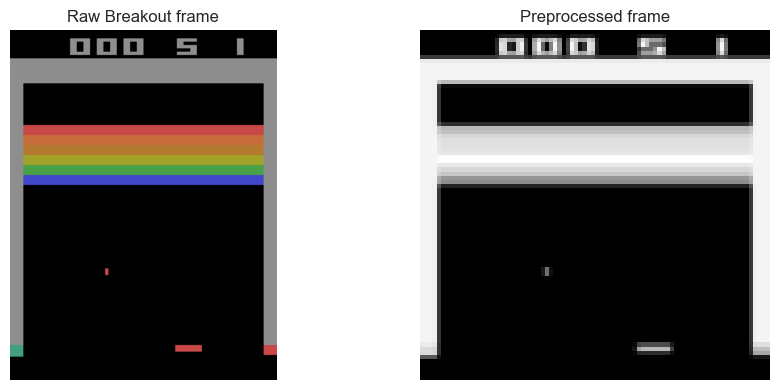

In [45]:
def resolve_env_id(preferred_env_id):
    candidate_ids = [
        preferred_env_id,
        'ALE/Breakout-v5',
        'Breakout-v4',
        'BreakoutNoFrameskip-v4',
    ]
    for env_id in candidate_ids:
        try:
            gym.spec(env_id)
            return env_id
        except Exception:
            continue
    available = [spec.id for spec in gym.envs.registry.values() if 'Breakout' in spec.id]
    raise RuntimeError(
        'Breakout environment is not registered. Make sure `ale-py` and Atari extras are installed, then rerun the first setup cell. '
        f'Available Breakout-like envs: {available[:10]}'
    )


def make_env(config: TrainConfig, render_mode=None):
    env_id = resolve_env_id(config.env_id)
    kwargs = {
        'render_mode': render_mode,
        'frameskip': 1,
        'repeat_action_probability': 0.0,
        'full_action_space': False,
    }
    try:
        env = gym.make(env_id, **kwargs)
    except TypeError:
        kwargs.pop('full_action_space', None)
        env = gym.make(env_id, **kwargs)
    return env


def get_action_meanings(env):
    try:
        return list(env.unwrapped.get_action_meanings())
    except Exception:
        return [str(i) for i in range(env.action_space.n)]


def find_fire_action(env):
    meanings = get_action_meanings(env)
    return meanings.index('FIRE') if 'FIRE' in meanings else None


def reset_with_fire(env, seed=None, config=None):
    obs, info = env.reset(seed=seed)
    fire_action = find_fire_action(env)
    if fire_action is not None:
        obs, _, terminated, truncated, info = env.step(fire_action)
        if terminated or truncated:
            obs, info = env.reset(seed=seed)
    noop_max = max(1, int(getattr(config, 'noop_max', 1) or 1))
    if noop_max > 1:
        noops = random.randint(1, noop_max)
        for _ in range(noops):
            obs, _, terminated, truncated, info = env.step(0)
            if terminated or truncated:
                obs, info = env.reset(seed=seed)
                if fire_action is not None:
                    obs, _, terminated, truncated, info = env.step(fire_action)
                    if terminated or truncated:
                        obs, info = env.reset(seed=seed)
    return obs, info


def preprocess_observation(observation, config: TrainConfig):
    image = Image.fromarray(observation)
    if config.grayscale:
        image = image.convert('L')
    image = image.resize((config.frame_size, config.frame_size), Image.BILINEAR)
    array = np.asarray(image, dtype=np.float32) / 255.0
    if config.grayscale:
        array = array[None, :, :]
    else:
        array = np.transpose(array, (2, 0, 1))
    return array


def init_state(observation, config: TrainConfig):
    frame = preprocess_observation(observation, config)
    return np.concatenate([frame] * config.frame_stack, axis=0).astype(np.float32)


def append_frame(state, observation, config: TrainConfig):
    frame = preprocess_observation(observation, config)
    channels = frame.shape[0]
    return np.concatenate([state[channels:], frame], axis=0).astype(np.float32)


def step_with_repeat(env, action, config: TrainConfig):
    total_reward = 0.0
    last_frames = []
    terminated = False
    truncated = False
    info = {}
    for _ in range(config.action_repeat):
        observation, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        last_frames.append(observation)
        if len(last_frames) > 2:
            last_frames.pop(0)
        if terminated or truncated:
            break
    if len(last_frames) == 2:
        pooled = np.maximum(last_frames[0], last_frames[1])
    else:
        pooled = last_frames[-1]
    return pooled, total_reward, terminated, truncated, info


env = make_env(BASE_CONFIG, render_mode='rgb_array')
action_meanings = get_action_meanings(env)
raw_obs, raw_info = reset_with_fire(env, seed=BASE_CONFIG.seed, config=BASE_CONFIG)
state = init_state(raw_obs, BASE_CONFIG)
print({'resolved_env': env.spec.id, 'actions': action_meanings, 'raw_obs': raw_obs.shape, 'state': state.shape})

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(raw_obs)
axes[0].set_title('Raw Breakout frame')
axes[0].axis('off')
axes[1].imshow(state[-1], cmap='gray')
axes[1].set_title('Preprocessed frame')
axes[1].axis('off')
plt.tight_layout()
plt.show()

env.close()

## 4. Replay Buffer и агент

Ниже реализованы буфер опыта, сверточная Q-сеть и сам агент DQN.


In [46]:
class ReplayBuffer:
    def __init__(self, capacity, state_shape):
        self.capacity = capacity
        self.state_shape = state_shape
        self.states = np.zeros((capacity, *state_shape), dtype=np.uint8)
        self.next_states = np.zeros((capacity, *state_shape), dtype=np.uint8)
        self.actions = np.zeros((capacity,), dtype=np.int64)
        self.rewards = np.zeros((capacity,), dtype=np.float32)
        self.dones = np.zeros((capacity,), dtype=np.bool_)
        self.position = 0
        self.full = False

    def __len__(self):
        return self.capacity if self.full else self.position

    def push(self, state, action, reward, next_state, done):
        self.states[self.position] = np.clip(state * 255.0, 0, 255).astype(np.uint8)
        self.next_states[self.position] = np.clip(next_state * 255.0, 0, 255).astype(np.uint8)
        self.actions[self.position] = action
        self.rewards[self.position] = reward
        self.dones[self.position] = done
        self.position = (self.position + 1) % self.capacity
        self.full = self.full or self.position == 0

    def sample(self, batch_size, device):
        indices = np.random.choice(len(self), size=batch_size, replace=False)
        states = torch.tensor(self.states[indices], dtype=torch.float32, device=device) / 255.0
        next_states = torch.tensor(self.next_states[indices], dtype=torch.float32, device=device) / 255.0
        actions = torch.tensor(self.actions[indices], dtype=torch.long, device=device)
        rewards = torch.tensor(self.rewards[indices], dtype=torch.float32, device=device)
        dones = torch.tensor(self.dones[indices], dtype=torch.float32, device=device)
        return states, actions, rewards, next_states, dones


class QNetwork(nn.Module):
    def __init__(self, input_channels, num_actions, hidden_dim=512, dueling=False):
        super().__init__()
        self.dueling = dueling
        self.features = nn.Sequential(
            nn.Conv2d(input_channels, 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU(),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, input_channels, 84, 84)
            feature_dim = self.features(dummy).view(1, -1).shape[1]
        if dueling:
            self.value_stream = nn.Sequential(
                nn.Linear(feature_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, 1),
            )
            self.advantage_stream = nn.Sequential(
                nn.Linear(feature_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, num_actions),
            )
        else:
            self.head = nn.Sequential(
                nn.Linear(feature_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, num_actions),
            )

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(start_dim=1)
        if self.dueling:
            value = self.value_stream(x)
            advantage = self.advantage_stream(x)
            return value + advantage - advantage.mean(dim=1, keepdim=True)
        return self.head(x)


class DQNAgent:
    def __init__(self, state_shape, num_actions, config: TrainConfig):
        self.config = config
        self.num_actions = num_actions
        self.online_net = QNetwork(state_shape[0], num_actions, config.hidden_dim, config.dueling).to(DEVICE)
        self.target_net = QNetwork(state_shape[0], num_actions, config.hidden_dim, config.dueling).to(DEVICE)
        self.target_net.load_state_dict(self.online_net.state_dict())
        self.target_net.eval()
        self.optimizer = optim.Adam(self.online_net.parameters(), lr=config.learning_rate)
        self.buffer = ReplayBuffer(config.replay_size, state_shape)

    def select_action(self, state, epsilon):
        if random.random() < epsilon:
            return random.randrange(self.num_actions)
        state_tensor = torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        with torch.no_grad():
            q_values = self.online_net(state_tensor)
        return int(q_values.argmax(dim=1).item())

    def state_value(self, state):
        state_tensor = torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
        with torch.no_grad():
            q_values = self.online_net(state_tensor)
        q_np = q_values.squeeze(0).detach().cpu().numpy()
        return float(q_np.max()), q_np

    def update(self):
        states, actions, rewards, next_states, dones = self.buffer.sample(self.config.batch_size, DEVICE)
        q_values = self.online_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)
        with torch.no_grad():
            if self.config.double_dqn:
                next_actions = self.online_net(next_states).argmax(dim=1, keepdim=True)
                next_q = self.target_net(next_states).gather(1, next_actions).squeeze(1)
            else:
                next_q = self.target_net(next_states).max(dim=1).values
            targets = rewards + self.config.gamma * next_q * (1.0 - dones)
        loss = F.smooth_l1_loss(q_values, targets)
        self.optimizer.zero_grad()
        loss.backward()
        if self.config.gradient_clip is not None:
            nn.utils.clip_grad_norm_(self.online_net.parameters(), self.config.gradient_clip)
        self.optimizer.step()
        return float(loss.item()), float(q_values.detach().mean().item())

    def sync_target(self):
        self.target_net.load_state_dict(self.online_net.state_dict())

    def save(self, path):
        payload = {
            'config': self.config.to_dict(),
            'model_state_dict': self.online_net.state_dict(),
            'target_state_dict': self.target_net.state_dict(),
        }
        torch.save(payload, path)

    def load(self, path):
        payload = torch.load(path, map_location=DEVICE)
        self.online_net.load_state_dict(payload['model_state_dict'])
        self.target_net.load_state_dict(payload.get('target_state_dict', payload['model_state_dict']))
        return payload


env = make_env(BASE_CONFIG)
obs, _ = reset_with_fire(env, seed=BASE_CONFIG.seed, config=BASE_CONFIG)
state_shape = init_state(obs, BASE_CONFIG).shape
num_actions = env.action_space.n
agent = DQNAgent(state_shape, num_actions, BASE_CONFIG)
mock_states = torch.zeros(2, *state_shape, device=DEVICE)
mock_q = agent.online_net(mock_states)
print({'state_shape': state_shape, 'num_actions': num_actions, 'q_shape': tuple(mock_q.shape)})
env.close()

{'state_shape': (4, 84, 84), 'num_actions': np.int64(4), 'q_shape': (2, 4)}


## 5. Вспомогательные функции

Функции для сохранения истории, расчёта метрик, построения графиков и анализа состояний.


In [47]:
def epsilon_by_step(step, config: TrainConfig):
    if step >= config.epsilon_decay_steps:
        return config.epsilon_end
    ratio = step / max(1, config.epsilon_decay_steps)
    return config.epsilon_start + ratio * (config.epsilon_end - config.epsilon_start)




### 5.1 Сохранение истории и базовые метрики


In [48]:
def checkpoint_paths(config: TrainConfig):
    return {
        'best': CHECKPOINT_DIR / f'{config.name}_best.pt',
        'last': CHECKPOINT_DIR / f'{config.name}_last.pt',
        'history': RESULTS_DIR / f'{config.name}_history.json',
        'summary': RESULTS_DIR / f'{config.name}_summary.json',
    }


def save_history(config: TrainConfig, history):
    paths = checkpoint_paths(config)
    with open(paths['history'], 'w', encoding='utf-8') as f:
        json.dump(history, f, ensure_ascii=False, indent=2)
    summary = {
        'config': config.to_dict(),
        'episodes_finished': len(history['episode_rewards']),
        'life_segments': len(history.get('life_rewards', [])),
        'best_eval_score': max(history['eval_scores']) if history['eval_scores'] else None,
        'final_episode_reward': history['episode_rewards'][-1] if history['episode_rewards'] else None,
        'last10_life_reward_mean': float(np.mean(history.get('life_rewards', [])[-10:])) if history.get('life_rewards') else None,
    }
    with open(paths['summary'], 'w', encoding='utf-8') as f:
        json.dump(summary, f, ensure_ascii=False, indent=2)


def load_history(config_name):
    path = RESULTS_DIR / f'{config_name}_history.json'
    if not path.exists():
        return None
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)


def moving_average(values, window=10):
    if not values:
        return np.array([])
    series = pd.Series(values, dtype=float)
    return series.rolling(window, min_periods=1).mean().to_numpy()


def display_video_file(path):
    path = Path(path)
    if not path.exists():
        print(f'Video not found: {path}')
        return
    display(Video(str(path), embed=True, html_attributes='controls loop autoplay'))




### 5.2 Работа с жизнями и диагностика rollout


In [49]:
def get_current_lives(env, info=None):
    if isinstance(info, dict):
        for key in ['lives', 'ale.lives']:
            if key in info and info[key] is not None:
                return int(info[key])
    try:
        return int(env.unwrapped.ale.lives())
    except Exception:
        return None


def maybe_fire_after_life_loss(env, previous_lives, current_lives):
    fire_action = find_fire_action(env)
    if fire_action is None:
        return None
    if previous_lives is None or current_lives is None:
        return None
    if current_lives >= previous_lives or current_lives <= 0:
        return None
    observation, reward, terminated, truncated, info = env.step(fire_action)
    return {
        'observation': observation,
        'reward': float(reward),
        'terminated': bool(terminated),
        'truncated': bool(truncated),
        'info': info,
        'action': fire_action,
    }


def compute_frame_diff_stats(frames):
    if len(frames) < 2:
        return {
            'mean_abs_diff': 0.0,
            'min_abs_diff': 0.0,
            'max_abs_diff': 0.0,
            'nearly_identical_pairs': 0,
            'total_pairs': max(0, len(frames) - 1),
            'unique_frame_ratio': 0.0,
        }
    diffs = []
    hashes = set()
    for idx, frame in enumerate(frames):
        hashes.add(frame[::8, ::8].tobytes())
        if idx == 0:
            continue
        prev = frames[idx - 1].astype(np.float32)
        cur = frame.astype(np.float32)
        diffs.append(float(np.mean(np.abs(cur - prev)) / 255.0))
    return {
        'mean_abs_diff': float(np.mean(diffs)),
        'min_abs_diff': float(np.min(diffs)),
        'max_abs_diff': float(np.max(diffs)),
        'nearly_identical_pairs': int(sum(diff < 0.01 for diff in diffs)),
        'total_pairs': len(diffs),
        'unique_frame_ratio': float(len(hashes) / max(1, len(frames))),
    }


def detect_idle_rollout(action_counts, frame_diff_stats, total_steps):
    if total_steps <= 0:
        return True
    noop_ratio = action_counts.get('NOOP', 0) / total_steps
    fire_ratio = action_counts.get('FIRE', 0) / total_steps
    dominant_ratio = max(action_counts.values(), default=0) / total_steps
    low_motion = frame_diff_stats['mean_abs_diff'] < ANALYSIS_MIN_FRAME_CHANGE
    return bool(low_motion or noop_ratio > 0.85 or fire_ratio > 0.85 or dominant_ratio > 0.95)


def load_summary(config_name):
    path = RESULTS_DIR / f'{config_name}_summary.json'
    if not path.exists():
        return None
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)


def select_best_available_checkpoint(experiments):
    candidates = []
    for name, config in experiments.items():
        paths = checkpoint_paths(config)
        if not paths['best'].exists():
            continue
        summary = load_summary(config.name) or {}
        best_eval_score = summary.get('best_eval_score')
        candidates.append({
            'experiment': name,
            'config': config,
            'checkpoint_kind': 'best',
            'checkpoint_path': str(paths['best']),
            'best_eval_score': float(best_eval_score) if best_eval_score is not None else float('-inf'),
            'summary': summary,
        })
    if not candidates:
        return None
    candidates.sort(key=lambda item: (item['best_eval_score'], Path(item['checkpoint_path']).stat().st_mtime), reverse=True)
    return candidates[0]


def evaluate_agent(
    agent: DQNAgent,
    config: TrainConfig,
    episodes=3,
    record_video=False,
    video_name=None,
    return_trace=False,
    seed=None,
    max_eval_steps=None,
):
    need_frames = record_video or return_trace
    env = make_env(config, render_mode='rgb_array' if need_frames else None)
    action_meanings = get_action_meanings(env)
    max_eval_steps = max_eval_steps or config.eval_max_steps
    scores = []
    trace = None
    frames_for_video = []
    per_episode = []
    global_action_counts = defaultdict(int)
    total_steps = 0
    terminated_reasons = []
    for episode_idx in range(episodes):
        obs, info = reset_with_fire(env, seed=None if seed is None else seed + episode_idx, config=config)
        state = init_state(obs, config)
        done = False
        episode_reward = 0.0
        episode_frames = []
        episode_values = []
        episode_actions = []
        episode_action_names = []
        episode_action_counts = defaultdict(int)
        life_events = []
        reward_per_life = []
        reward_since_last_life = 0.0
        num_steps = 0
        last_info = info
        previous_lives = get_current_lives(env, info)
        terminated_reason = 'environment_done'
        while not done and num_steps < max_eval_steps:
            state_value, q_values = agent.state_value(state)
            action = int(np.argmax(q_values))
            action_name = action_meanings[action] if action < len(action_meanings) else str(action)
            next_obs, reward, terminated, truncated, info = step_with_repeat(env, action, config)
            current_lives = get_current_lives(env, info)
            life_lost = previous_lives is not None and current_lives is not None and current_lives < previous_lives
            if previous_lives is not None and current_lives is not None and current_lives < previous_lives:
                reward_per_life.append(float(reward_since_last_life))
                reward_since_last_life = 0.0
                life_event = {
                    'frame_index': num_steps,
                    'lives_before': int(previous_lives),
                    'lives_after': int(current_lives),
                    'action': action_name,
                }
                resume_payload = None if terminated or truncated else maybe_fire_after_life_loss(env, previous_lives, current_lives)
                if resume_payload is not None:
                    next_obs = resume_payload['observation']
                    reward += resume_payload['reward']
                    terminated = terminated or resume_payload['terminated']
                    truncated = truncated or resume_payload['truncated']
                    info = resume_payload['info']
                    life_event['resume_action'] = action_meanings[resume_payload['action']] if resume_payload['action'] < len(action_meanings) else str(resume_payload['action'])
                    current_lives = get_current_lives(env, info)
                life_events.append(life_event)
            done = terminated or truncated
            episode_reward += reward
            reward_since_last_life += reward
            episode_values.append(state_value)
            episode_actions.append(action)
            episode_action_names.append(action_name)
            episode_action_counts[action_name] += 1
            global_action_counts[action_name] += 1
            if need_frames:
                current_frame = env.render() if getattr(env, 'render_mode', None) == 'rgb_array' else next_obs
                if current_frame is not None:
                    episode_frames.append(np.asarray(current_frame))
            state = init_state(next_obs, config) if life_lost else append_frame(state, next_obs, config)
            num_steps += 1
            total_steps += 1
            last_info = info
            previous_lives = current_lives
        reward_per_life.append(float(reward_since_last_life))
        if not done and num_steps >= max_eval_steps:
            terminated_reason = 'step_limit'
        elif truncated:
            terminated_reason = 'truncated'
        elif terminated:
            terminated_reason = 'terminated'
        frame_diff_stats = compute_frame_diff_stats(episode_frames)
        idle_rollout = detect_idle_rollout(episode_action_counts, frame_diff_stats, num_steps)
        episode_summary = {
            'episode_index': episode_idx,
            'score': float(episode_reward),
            'num_steps': int(num_steps),
            'num_frames': int(len(episode_frames)),
            'terminated_reason': terminated_reason,
            'action_counts': dict(episode_action_counts),
            'frame_diff_stats': frame_diff_stats,
            'life_events': life_events,
            'reward_per_life': reward_per_life,
            'idle_rollout': bool(idle_rollout),
            'resumed_after_life_loss': any('resume_action' in event for event in life_events),
        }
        scores.append(float(episode_reward))
        terminated_reasons.append(terminated_reason)
        per_episode.append(episode_summary)
        if episode_idx == 0 and return_trace:
            trace = {
                'frames': episode_frames,
                'state_values': episode_values,
                'actions': episode_actions,
                'action_names': episode_action_names,
                'score': float(episode_reward),
                'life_events': life_events,
                'num_steps': int(num_steps),
                'terminated_reason': terminated_reason,
                'frame_diff_stats': frame_diff_stats,
                'action_counts': dict(episode_action_counts),
                'idle_rollout': bool(idle_rollout),
                'reward_per_life': reward_per_life,
            }
        if episode_idx == 0 and record_video:
            frames_for_video = episode_frames
    env.close()

    video_path = None
    if record_video and frames_for_video:
        video_path = VIDEO_DIR / f"{video_name or config.name}.mp4"
        imageio.mimsave(video_path, frames_for_video, fps=30)
    frame_diff_stats = trace['frame_diff_stats'] if trace else {'mean_abs_diff': 0.0, 'min_abs_diff': 0.0, 'max_abs_diff': 0.0, 'nearly_identical_pairs': 0, 'total_pairs': 0, 'unique_frame_ratio': 0.0}
    result = {
        'mean_score': float(np.mean(scores)) if scores else 0.0,
        'scores': scores,
        'video_path': str(video_path) if video_path else None,
        'num_steps': int(total_steps),
        'terminated_reason': terminated_reasons[0] if len(terminated_reasons) == 1 else terminated_reasons,
        'action_counts': dict(global_action_counts),
        'frame_diff_stats': frame_diff_stats,
        'life_events': trace['life_events'] if trace else [],
        'per_episode': per_episode,
    }
    if return_trace:
        result['trace'] = trace
    return result


def train_agent(config: TrainConfig):
    env = make_env(config)
    obs, info = reset_with_fire(env, seed=config.seed, config=config)
    state = init_state(obs, config)
    agent = DQNAgent(state.shape, env.action_space.n, config)
    history = defaultdict(list)
    best_eval_score = -float('inf')
    episode_reward = 0.0
    episode_length = 0
    episode_idx = 0
    life_reward = 0.0
    previous_lives = get_current_lives(env)
    progress = tqdm(range(1, config.max_steps + 1), desc=f'train:{config.name}')

    for step in progress:
        epsilon = epsilon_by_step(step, config)
        if step <= config.warmup_random_steps:
            action = env.action_space.sample()
        else:
            action = agent.select_action(state, epsilon)

        next_obs, reward, terminated, truncated, info = step_with_repeat(env, action, config)
        current_lives = get_current_lives(env, info)
        life_lost = previous_lives is not None and current_lives is not None and current_lives < previous_lives
        resume_payload = None if terminated or truncated else maybe_fire_after_life_loss(env, previous_lives, current_lives)
        if resume_payload is not None:
            next_obs = resume_payload['observation']
            reward += resume_payload['reward']
            terminated = terminated or resume_payload['terminated']
            truncated = truncated or resume_payload['truncated']
            info = resume_payload['info']
            current_lives = get_current_lives(env, info)
        done = terminated or truncated
        done_for_buffer = done or (config.terminal_on_life_loss and life_lost)
        clipped_reward = float(np.sign(reward)) if config.reward_clip else float(reward)
        next_state = init_state(next_obs, config) if (config.terminal_on_life_loss and life_lost) else append_frame(state, next_obs, config)
        agent.buffer.push(state, action, clipped_reward, next_state, done_for_buffer)

        episode_reward += reward
        episode_length += 1
        life_reward += reward
        state = next_state
        previous_lives = current_lives
        if life_lost:
            history['life_rewards'].append(float(life_reward))
            history['life_loss_steps'].append(step)
            life_reward = 0.0

        if len(agent.buffer) >= max(config.batch_size, config.learning_starts) and step % config.train_every == 0:
            loss, mean_q = agent.update()
            history['losses'].append(loss)
            history['loss_steps'].append(step)
            history['mean_q'].append(mean_q)
            history['mean_q_steps'].append(step)

        if step % config.target_update_interval == 0:
            agent.sync_target()

        if step % config.eval_interval == 0:
            eval_result = evaluate_agent(agent, config, episodes=config.eval_episodes, record_video=False, seed=config.seed + step, max_eval_steps=config.eval_max_steps)
            history['eval_steps'].append(step)
            history['eval_scores'].append(eval_result['mean_score'])
            if eval_result['mean_score'] > best_eval_score:
                best_eval_score = eval_result['mean_score']
                agent.save(checkpoint_paths(config)['best'])
            progress.set_postfix({'eps': round(epsilon, 3), 'eval': round(eval_result['mean_score'], 2), 'buffer': len(agent.buffer)})

        if done:
            history['episode_rewards'].append(float(episode_reward))
            history['episode_lengths'].append(int(episode_length))
            history['episode_indices'].append(episode_idx)
            history['episode_end_steps'].append(step)
            if life_reward != 0.0 or not history['life_rewards']:
                history['life_rewards'].append(float(life_reward))
                history['life_loss_steps'].append(step)
            episode_idx += 1
            obs, info = reset_with_fire(env, seed=config.seed + episode_idx, config=config)
            state = init_state(obs, config)
            episode_reward = 0.0
            episode_length = 0
            life_reward = 0.0
            previous_lives = get_current_lives(env, info)

    agent.save(checkpoint_paths(config)['last'])
    if not checkpoint_paths(config)['best'].exists():
        agent.save(checkpoint_paths(config)['best'])
    env.close()

    history = {k: list(v) for k, v in history.items()}
    history['config'] = config.to_dict()
    save_history(config, history)
    return agent, history


def load_agent_for_config(config: TrainConfig, kind='best', checkpoint_path=None):
    env = make_env(config)
    obs, _ = reset_with_fire(env, seed=config.seed, config=config)
    state_shape = init_state(obs, config).shape
    num_actions = env.action_space.n
    env.close()
    agent = DQNAgent(state_shape, num_actions, config)
    path = Path(checkpoint_path) if checkpoint_path is not None else checkpoint_paths(config)[kind]
    agent.load(path)
    return agent




### 5.3 Визуализация обучения


In [50]:
def plot_training_curves(histories):
    if not histories:
        print('Нет историй для отображения.')
        return
    fig, axes = plt.subplots(2, 2, figsize=(16, 8))
    axes = axes.flatten()
    for name, history in histories.items():
        if history.get('losses'):
            axes[0].plot(history['loss_steps'], moving_average(history['losses'], 20), label=name)
        if history.get('episode_rewards'):
            axes[1].plot(history['episode_end_steps'], moving_average(history['episode_rewards'], 10), label=name)
        if history.get('eval_scores'):
            axes[2].plot(history['eval_steps'], history['eval_scores'], marker='o', label=name)
        if history.get('life_rewards'):
            axes[3].plot(history['life_loss_steps'], moving_average(history['life_rewards'], 20), label=name)
    axes[0].set_title('Loss (moving average)')
    axes[0].set_xlabel('training step')
    axes[1].set_title('Episode reward (moving average)')
    axes[1].set_xlabel('training step')
    axes[2].set_title('Evaluation score')
    axes[2].set_xlabel('training step')
    axes[3].set_title('Life reward (moving average)')
    axes[3].set_xlabel('training step')
    for ax in axes:
        ax.grid(alpha=0.3)
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend()
    plt.tight_layout()
    plt.show()


def find_local_peaks(values, top_k=5, min_distance=10):
    values = np.asarray(values, dtype=float)
    if values.size == 0:
        return []
    candidates = []
    for idx in range(1, len(values) - 1):
        if values[idx] >= values[idx - 1] and values[idx] >= values[idx + 1]:
            candidates.append((idx, values[idx]))
    candidates.sort(key=lambda item: item[1], reverse=True)
    selected = []
    for idx, score in candidates:
        if all(abs(idx - taken) >= min_distance for taken, _ in selected):
            selected.append((idx, score))
        if len(selected) == top_k:
            break
    if not selected and len(values) > 0:
        best = int(values.argmax())
        selected = [(best, float(values[best]))]
    return selected




### 5.4 Анализ оценок состояний


In [51]:
def analyze_state_values(
    config: TrainConfig,
    checkpoint_kind='best',
    top_k=5,
    seed=SEED + 123,
    max_eval_steps=None,
    ignore_idle_prefix=None,
    min_frame_change=None,
):
    agent = load_agent_for_config(config, kind=checkpoint_kind)
    max_eval_steps = ANALYSIS_MAX_EVAL_STEPS if max_eval_steps is None else max_eval_steps
    ignore_idle_prefix = ANALYSIS_IGNORE_IDLE_PREFIX if ignore_idle_prefix is None else ignore_idle_prefix
    min_frame_change = ANALYSIS_MIN_FRAME_CHANGE if min_frame_change is None else min_frame_change
    result = evaluate_agent(
        agent,
        config,
        episodes=ANALYSIS_EPISODES,
        record_video=RECORD_VIDEO,
        video_name=f'{config.name}_{checkpoint_kind}',
        return_trace=True,
        seed=seed,
        max_eval_steps=max_eval_steps,
    )
    trace = result.get('trace')
    values = np.asarray(trace['state_values'] if trace else [], dtype=float)
    frames = trace['frames'] if trace else []
    action_names = trace['action_names'] if trace else []
    if trace:
        trace_export = {
            'config_name': config.name,
            'checkpoint_kind': checkpoint_kind,
            'score': trace['score'],
            'num_steps': trace['num_steps'],
            'terminated_reason': trace['terminated_reason'],
            'action_counts': trace['action_counts'],
            'life_events': trace['life_events'],
            'frame_diff_stats': trace['frame_diff_stats'],
            'idle_rollout': trace['idle_rollout'],
            'reward_per_life': trace['reward_per_life'],
        }
        with open(RESULTS_DIR / f'{config.name}_{checkpoint_kind}_eval_trace.json', 'w', encoding='utf-8') as f:
            json.dump(trace_export, f, ensure_ascii=False, indent=2)
    valid_indices = []
    if len(frames) >= 2:
        for idx in range(1, len(frames)):
            frame_diff = float(np.mean(np.abs(frames[idx].astype(np.float32) - frames[idx - 1].astype(np.float32))) / 255.0)
            if idx >= ignore_idle_prefix and frame_diff >= min_frame_change:
                valid_indices.append(idx)
    filtered_values = values[valid_indices] if len(valid_indices) else values
    peaks = []
    if len(filtered_values):
        filtered_peaks = find_local_peaks(filtered_values.tolist(), top_k=top_k)
        peaks = [(valid_indices[idx], score) if len(valid_indices) else (idx, score) for idx, score in filtered_peaks]

    plt.figure(figsize=(12, 4))
    plt.plot(values, label='max Q(s, a)', alpha=0.8)
    if valid_indices:
        plt.scatter(valid_indices, values[valid_indices], s=8, alpha=0.15, label='frames used for peak search')
    for idx, score in peaks:
        plt.scatter(idx, score, color='crimson')
        plt.text(idx, score, f'{idx}', fontsize=9)
    plt.title(f'State-value trace: {config.name}')
    plt.xlabel('frame index')
    plt.ylabel('max Q(s, a)')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

    warning_messages = []
    if trace and trace.get('idle_rollout'):
        warning_messages.append('Idle rollout detected: action distribution or frame dynamics suggest the agent is mostly stuck.')
    if len(values) and float(values.max() - values.min()) < 0.05:
        warning_messages.append('State-value range is very narrow; the model still weakly separates good and bad states.')
    if not valid_indices:
        warning_messages.append('Peak search had no non-idle frames after filtering, so peaks are based on the raw trace.')
    for message in warning_messages:
        print('WARNING:', message)

    if trace and trace['frames'] and peaks:
        cols = min(len(peaks), 3)
        rows = int(math.ceil(len(peaks) / cols)) if cols else 1
        fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
        axes = np.atleast_1d(axes).reshape(rows, cols)
        for ax in axes.flat:
            ax.axis('off')
        for ax, (idx, score) in zip(axes.flat, peaks):
            ax.imshow(trace['frames'][idx])
            ax.set_title(f'peak={score:.2f}, frame={idx}, action={action_names[idx] if idx < len(action_names) else "?"}')
            ax.axis('off')
        plt.tight_layout()
        plt.show()

    if result.get('video_path'):
        display_video_file(result['video_path'])

    life_by_frame = {}
    current_life = None
    if trace:
        for event in trace['life_events']:
            life_by_frame[event['frame_index']] = event['lives_after']
    peak_table = pd.DataFrame([
        {
            'frame_index': idx,
            'state_value': score,
            'action': action_names[idx] if idx < len(action_names) else None,
            'score_so_far': trace['score'] if trace else None,
            'life_after_event': life_by_frame.get(idx),
        }
        for idx, score in peaks
    ])
    display(peak_table)
    return result




### 5.5 Короткий smoke-пример для проверки графиков


## 6. Оценка и обучение модели

Сначала идут функции для resume и evaluation, затем основной цикл обучения.


### 6.1 Resume и служебные функции


In [52]:
FIXED_FINAL_EVAL_SEEDS = [int(SEED + 137 * (idx + 1)) for idx in range(FINAL_EVAL_EPISODES)]




### 6.2 Оценка агента


In [53]:
def ensure_config_defaults(config: TrainConfig):
    defaults = {
        'resume_from_checkpoint': None,
        'resume_history_name': None,
        'resume_summary_name': None,
        'resume_epsilon_start': None,
        'final_eval_episodes': FINAL_EVAL_EPISODES,
        'final_eval_max_steps': FINAL_EVAL_MAX_STEPS,
        'require_resume_checkpoint': True,
    }
    for key, value in defaults.items():
        if not hasattr(config, key):
            setattr(config, key, value)
    return config


def infer_last_training_step(history):
    if not history:
        return 0
    candidates = []
    for key in ['episode_end_steps', 'life_loss_steps', 'eval_steps', 'loss_steps', 'mean_q_steps']:
        values = history.get(key)
        if isinstance(values, list) and values:
            candidates.append(int(max(values)))
    return int(max(candidates, default=0))


def epsilon_by_step(step, config: TrainConfig):
    start_value = config.resume_epsilon_start if getattr(config, 'resume_epsilon_start', None) is not None else config.epsilon_start
    if step >= config.epsilon_decay_steps:
        return config.epsilon_end
    ratio = step / max(1, config.epsilon_decay_steps)
    return start_value + ratio * (config.epsilon_end - start_value)


def save_history(config: TrainConfig, history):
    paths = checkpoint_paths(config)
    history = dict(history)
    history['config'] = config.to_dict()
    with open(paths['history'], 'w', encoding='utf-8') as f:
        json.dump(history, f, ensure_ascii=False, indent=2)
    summary = {
        'config': config.to_dict(),
        'episodes_finished': len(history.get('episode_rewards', [])),
        'life_segments': len(history.get('life_rewards', [])),
        'best_eval_score': max(history.get('eval_scores', [])) if history.get('eval_scores') else None,
        'best_median_score': max(history.get('eval_median_scores', [])) if history.get('eval_median_scores') else None,
        'final_episode_reward': history.get('episode_rewards', [])[-1] if history.get('episode_rewards') else None,
        'last10_life_reward_mean': float(np.mean(history.get('life_rewards', [])[-10:])) if history.get('life_rewards') else None,
        'final_step': infer_last_training_step(history),
        'start_step': history.get('start_step'),
        'target_step': history.get('target_step'),
        'remaining_steps_at_start': history.get('remaining_steps_at_start'),
    }
    with open(paths['summary'], 'w', encoding='utf-8') as f:
        json.dump(summary, f, ensure_ascii=False, indent=2)


def resolve_resume_start_step(config: TrainConfig, history, payload):
    start_step = infer_last_training_step(history)
    if payload is not None:
        metadata = payload.get('metadata') if isinstance(payload, dict) else None
        if isinstance(metadata, dict):
            start_step = max(start_step, int(metadata.get('step', 0) or 0))
    resume_summary_name = getattr(config, 'resume_summary_name', None) or getattr(config, 'resume_history_name', None)
    if start_step == 0 and resume_summary_name:
        resume_summary = load_summary(resume_summary_name) or {}
        start_step = max(start_step, int(resume_summary.get('final_step', 0) or 0))
    return int(start_step)


def resume_summary_exists(config: TrainConfig):
    summary_name = getattr(config, 'resume_summary_name', None) or getattr(config, 'resume_history_name', None)
    if not summary_name:
        return False
    return (RESULTS_DIR / f'{summary_name}_summary.json').exists()




### 6.3 Основной цикл обучения


In [54]:
def evaluate_agent(
    agent: DQNAgent,
    config: TrainConfig,
    episodes=3,
    record_video=False,
    video_name=None,
    return_trace=False,
    seed=None,
    max_eval_steps=None,
):
    ensure_config_defaults(config)
    need_frames = record_video or return_trace
    env = make_env(config, render_mode='rgb_array' if need_frames else None)
    action_meanings = get_action_meanings(env)
    max_eval_steps = max_eval_steps or config.eval_max_steps
    scores = []
    trace = None
    frames_for_video = []
    per_episode = []
    global_action_counts = defaultdict(int)
    total_steps = 0
    terminated_reasons = []
    for episode_idx in range(episodes):
        episode_seed = None if seed is None else seed + episode_idx
        obs, info = reset_with_fire(env, seed=episode_seed, config=config)
        state = init_state(obs, config)
        done = False
        episode_reward = 0.0
        episode_frames = []
        episode_values = []
        episode_actions = []
        episode_action_names = []
        episode_action_counts = defaultdict(int)
        life_events = []
        reward_per_life = []
        reward_since_last_life = 0.0
        num_steps = 0
        previous_lives = get_current_lives(env, info)
        terminated_reason = 'environment_done'
        while not done and num_steps < max_eval_steps:
            state_value, q_values = agent.state_value(state)
            action = int(np.argmax(q_values))
            action_name = action_meanings[action] if action < len(action_meanings) else str(action)
            next_obs, reward, terminated, truncated, info = step_with_repeat(env, action, config)
            current_lives = get_current_lives(env, info)
            life_lost = previous_lives is not None and current_lives is not None and current_lives < previous_lives
            if life_lost:
                reward_per_life.append(float(reward_since_last_life))
                reward_since_last_life = 0.0
                life_event = {
                    'frame_index': num_steps,
                    'lives_before': int(previous_lives),
                    'lives_after': int(current_lives),
                    'action': action_name,
                }
                resume_payload = None if terminated or truncated else maybe_fire_after_life_loss(env, previous_lives, current_lives)
                if resume_payload is not None:
                    next_obs = resume_payload['observation']
                    reward += resume_payload['reward']
                    terminated = terminated or resume_payload['terminated']
                    truncated = truncated or resume_payload['truncated']
                    info = resume_payload['info']
                    life_event['resume_action'] = action_meanings[resume_payload['action']] if resume_payload['action'] < len(action_meanings) else str(resume_payload['action'])
                    current_lives = get_current_lives(env, info)
                life_events.append(life_event)
            done = terminated or truncated
            episode_reward += reward
            reward_since_last_life += reward
            episode_values.append(float(state_value))
            episode_actions.append(int(action))
            episode_action_names.append(action_name)
            episode_action_counts[action_name] += 1
            global_action_counts[action_name] += 1
            if need_frames:
                current_frame = env.render() if getattr(env, 'render_mode', None) == 'rgb_array' else next_obs
                if current_frame is not None:
                    episode_frames.append(np.asarray(current_frame))
            state = init_state(next_obs, config) if life_lost else append_frame(state, next_obs, config)
            num_steps += 1
            total_steps += 1
            previous_lives = current_lives
        reward_per_life.append(float(reward_since_last_life))
        if not done and num_steps >= max_eval_steps:
            terminated_reason = 'step_limit'
        elif truncated:
            terminated_reason = 'truncated'
        elif terminated:
            terminated_reason = 'terminated'
        frame_diff_stats = compute_frame_diff_stats(episode_frames)
        idle_rollout = detect_idle_rollout(episode_action_counts, frame_diff_stats, num_steps)
        episode_summary = {
            'episode_index': episode_idx,
            'seed': episode_seed,
            'score': float(episode_reward),
            'num_steps': int(num_steps),
            'num_frames': int(len(episode_frames)),
            'terminated_reason': terminated_reason,
            'action_counts': dict(episode_action_counts),
            'frame_diff_stats': frame_diff_stats,
            'life_events': life_events,
            'reward_per_life': reward_per_life,
            'idle_rollout': bool(idle_rollout),
            'remaining_lives': get_current_lives(env, info),
        }
        scores.append(float(episode_reward))
        terminated_reasons.append(terminated_reason)
        per_episode.append(episode_summary)
        if return_trace and trace is None:
            trace = {
                'score': float(episode_reward),
                'num_steps': int(num_steps),
                'terminated_reason': terminated_reason,
                'state_values': episode_values,
                'frames': episode_frames,
                'actions': episode_actions,
                'action_names': episode_action_names,
                'action_counts': dict(episode_action_counts),
                'frame_diff_stats': frame_diff_stats,
                'life_events': life_events,
                'idle_rollout': bool(idle_rollout),
                'reward_per_life': reward_per_life,
            }
        if episode_idx == 0 and record_video:
            frames_for_video = episode_frames
    env.close()

    video_path = None
    if record_video and frames_for_video:
        video_path = VIDEO_DIR / f"{video_name or config.name}.mp4"
        imageio.mimsave(video_path, frames_for_video, fps=30)
    result = {
        'mean_score': float(np.mean(scores)) if scores else 0.0,
        'median_score': float(np.median(scores)) if scores else 0.0,
        'scores': scores,
        'video_path': str(video_path) if video_path else None,
        'num_steps': int(total_steps),
        'terminated_reason': terminated_reasons[0] if len(terminated_reasons) == 1 else terminated_reasons,
        'action_counts': dict(global_action_counts),
        'frame_diff_stats': trace['frame_diff_stats'] if trace else (per_episode[0]['frame_diff_stats'] if per_episode else {}),
        'idle_rollout': bool(trace['idle_rollout']) if trace else (bool(per_episode[0]['idle_rollout']) if per_episode else True),
        'life_events': trace['life_events'] if trace else [],
        'per_episode': per_episode,
    }
    if return_trace:
        result['trace'] = trace
    return result




### 6.4 Загрузка сохранённой модели


In [55]:
def train_agent(config: TrainConfig):
    ensure_config_defaults(config)
    env = make_env(config)
    obs, info = reset_with_fire(env, seed=config.seed, config=config)
    state = init_state(obs, config)
    agent = DQNAgent(state.shape, env.action_space.n, config)
    resume_path = Path(config.resume_from_checkpoint) if getattr(config, 'resume_from_checkpoint', None) else None
    resume_checkpoint_found = bool(resume_path is not None and resume_path.exists())
    resume_summary_found = bool(resume_summary_exists(config))
    if getattr(config, 'require_resume_checkpoint', False):
        if not resume_checkpoint_found:
            env.close()
            raise RuntimeError(f"Required resume checkpoint not found for {config.name}: {resume_path}")
        if not resume_summary_found:
            env.close()
            raise RuntimeError(f"Required resume summary not found for {config.name}: {getattr(config, 'resume_summary_name', None) or getattr(config, 'resume_history_name', None)}")

    history = None if FORCE_RETRAIN else load_history(config.name)
    if history is None and getattr(config, 'resume_history_name', None):
        resume_history = load_history(config.resume_history_name)
        if resume_history is not None:
            history = json.loads(json.dumps(resume_history))
    if history is None:
        history = defaultdict(list)
    else:
        history = defaultdict(list, {k: list(v) if isinstance(v, list) else v for k, v in history.items()})

    payload = None
    if resume_checkpoint_found:
        try:
            payload = agent.load(resume_path)
        except RuntimeError as exc:
            env.close()
            raise RuntimeError(f"Checkpoint shape/config mismatch for {config.name}: {resume_path}") from exc

    start_step = resolve_resume_start_step(config, history, payload)
    target_step = int(config.max_steps)
    remaining_steps = max(0, target_step - start_step)
    print({
        'config': config.name,
        'resume_checkpoint_found': resume_checkpoint_found,
        'resume_summary_found': resume_summary_found,
        'resume_checkpoint': str(resume_path) if resume_checkpoint_found else None,
        'start_step': int(start_step),
        'target_step': target_step,
        'remaining_steps': int(remaining_steps),
    })
    if getattr(config, 'require_resume_checkpoint', False) and start_step <= 0:
        env.close()
        raise RuntimeError(f"Resume is required for {config.name}, but resolved start_step={start_step}")
    if start_step >= target_step:
        env.close()
        history = {k: list(v) if isinstance(v, list) else v for k, v in history.items()}
        history['config'] = config.to_dict()
        return agent, history

    best_eval_score = max(history.get('eval_scores', [])) if history.get('eval_scores') else -float('inf')
    best_eval_median = max(history.get('eval_median_scores', [])) if history.get('eval_median_scores') else -float('inf')
    history['start_step'] = int(start_step)
    history['target_step'] = int(target_step)
    history['remaining_steps_at_start'] = int(remaining_steps)
    episode_reward = 0.0
    episode_length = 0
    episode_idx = len(history.get('episode_rewards', []))
    life_reward = 0.0
    previous_lives = get_current_lives(env)
    progress = tqdm(range(start_step + 1, target_step + 1), desc=f'train:{config.name}')

    for step in progress:
        local_step = step - start_step
        epsilon = epsilon_by_step(local_step, config)
        if local_step <= config.warmup_random_steps:
            action = env.action_space.sample()
        else:
            action = agent.select_action(state, epsilon)

        next_obs, reward, terminated, truncated, info = step_with_repeat(env, action, config)
        current_lives = get_current_lives(env, info)
        life_lost = previous_lives is not None and current_lives is not None and current_lives < previous_lives
        resume_payload = None if terminated or truncated else maybe_fire_after_life_loss(env, previous_lives, current_lives)
        if resume_payload is not None:
            next_obs = resume_payload['observation']
            reward += resume_payload['reward']
            terminated = terminated or resume_payload['terminated']
            truncated = truncated or resume_payload['truncated']
            info = resume_payload['info']
            current_lives = get_current_lives(env, info)
        done = terminated or truncated
        done_for_buffer = done or (config.terminal_on_life_loss and life_lost)
        clipped_reward = float(np.sign(reward)) if config.reward_clip else float(reward)
        next_state = init_state(next_obs, config) if (config.terminal_on_life_loss and life_lost) else append_frame(state, next_obs, config)
        agent.buffer.push(state, action, clipped_reward, next_state, done_for_buffer)

        episode_reward += reward
        episode_length += 1
        life_reward += reward
        state = next_state
        previous_lives = current_lives
        if life_lost:
            history['life_rewards'].append(float(life_reward))
            history['life_loss_steps'].append(int(step))
            life_reward = 0.0

        if len(agent.buffer) >= max(config.batch_size, config.learning_starts) and step % config.train_every == 0:
            loss, mean_q = agent.update()
            history['losses'].append(float(loss))
            history['loss_steps'].append(int(step))
            history['mean_q'].append(float(mean_q))
            history['mean_q_steps'].append(int(step))

        if step % config.target_update_interval == 0:
            agent.sync_target()

        if step % config.eval_interval == 0:
            eval_result = evaluate_agent(
                agent,
                config,
                episodes=config.eval_episodes,
                record_video=False,
                seed=config.seed + step,
                max_eval_steps=config.eval_max_steps,
            )
            history['eval_steps'].append(int(step))
            history['eval_scores'].append(float(eval_result['mean_score']))
            history['eval_median_scores'].append(float(eval_result['median_score']))
            current_mean = float(eval_result['mean_score'])
            current_median = float(eval_result['median_score'])
            if (current_mean > best_eval_score) or (current_mean == best_eval_score and current_median > best_eval_median):
                best_eval_score = current_mean
                best_eval_median = current_median
                agent.save(checkpoint_paths(config)['best'])
            progress.set_postfix({'eps': round(epsilon, 3), 'eval': round(eval_result['mean_score'], 2), 'buffer': len(agent.buffer)})

        if done:
            history['episode_rewards'].append(float(episode_reward))
            history['episode_lengths'].append(int(episode_length))
            history['episode_indices'].append(int(episode_idx))
            history['episode_end_steps'].append(int(step))
            if life_reward != 0.0 or not history['life_rewards']:
                history['life_rewards'].append(float(life_reward))
                history['life_loss_steps'].append(int(step))
            episode_idx += 1
            obs, info = reset_with_fire(env, seed=config.seed + episode_idx, config=config)
            state = init_state(obs, config)
            episode_reward = 0.0
            episode_length = 0
            life_reward = 0.0
            previous_lives = get_current_lives(env, info)

    agent.save(checkpoint_paths(config)['last'])
    if not checkpoint_paths(config)['best'].exists():
        agent.save(checkpoint_paths(config)['best'])
    env.close()

    history = {k: list(v) if isinstance(v, list) else v for k, v in history.items()}
    history['config'] = config.to_dict()
    save_history(config, history)
    return agent, history




## 7. Конфигурации экспериментов и запуск

В этом разделе задаются сравниваемые конфигурации и запускается обучение выбранного эксперимента.


### 7.1 Набор конфигураций


In [56]:
EXPERIMENTS = {
    'baseline': replace(
        BASE_CONFIG,
        name='baseline',
        frame_stack=1,
        action_repeat=1,
        reward_clip=False,
        terminal_on_life_loss=False,
        noop_max=1,
        double_dqn=False,
        dueling=False,
    ),
    'preprocessing': replace(
        BASE_CONFIG,
        name='preprocessing',
        frame_stack=4,
        action_repeat=4,
        reward_clip=False,
        terminal_on_life_loss=True,
        noop_max=30,
        double_dqn=False,
        dueling=False,
    ),
    'reward_clipping': replace(
        BASE_CONFIG,
        name='reward_clipping',
        frame_stack=4,
        action_repeat=4,
        reward_clip=True,
        terminal_on_life_loss=True,
        noop_max=30,
        double_dqn=False,
        dueling=False,
    ),
    'best_model': replace(
        BASE_CONFIG,
        name='best_model',
        frame_stack=4,
        action_repeat=4,
        reward_clip=True,
        terminal_on_life_loss=True,
        noop_max=30,
        learning_rate=5e-5,
        epsilon_decay_steps=300_000,
        double_dqn=True,
        dueling=True,
    ),
    'preprocessing_tuned_resume': replace(
        BASE_CONFIG,
        name='preprocessing_tuned_resume',
        frame_stack=4,
        action_repeat=4,
        reward_clip=False,
        terminal_on_life_loss=True,
        noop_max=30,
        learning_rate=2.5e-5,
        batch_size=32,
        replay_size=200_000,
        learning_starts=0,
        warmup_random_steps=0,
        train_every=4,
        target_update_interval=5_000,
        epsilon_decay_steps=100_000,
        max_steps=475_000,
        eval_interval=25_000,
        eval_episodes=2,
        eval_max_steps=3_000,
        double_dqn=False,
        dueling=False,
        resume_from_checkpoint=str(CHECKPOINT_DIR / 'preprocessing_best.pt'),
        resume_history_name='preprocessing',
        resume_summary_name='preprocessing',
        resume_epsilon_start=0.05,
        final_eval_episodes=FINAL_EVAL_EPISODES,
        final_eval_max_steps=FINAL_EVAL_MAX_STEPS,
        require_resume_checkpoint=True,
    ),
    'preprocessing_strong_from_scratch': replace(
        BASE_CONFIG,
        name='preprocessing_strong_from_scratch',
        frame_stack=4,
        action_repeat=4,
        reward_clip=False,
        terminal_on_life_loss=True,
        noop_max=30,
        learning_rate=5e-5,
        batch_size=32,
        replay_size=200_000,
        learning_starts=20_000,
        warmup_random_steps=20_000,
        train_every=4,
        target_update_interval=5_000,
        epsilon_start=1.0,
        epsilon_end=0.01,
        epsilon_decay_steps=325_000,
        max_steps=550_000,
        eval_interval=25_000,
        eval_episodes=2,
        eval_max_steps=4_000,
        double_dqn=False,
        dueling=False,
        resume_from_checkpoint=None,
        resume_history_name=None,
        resume_summary_name=None,
        resume_epsilon_start=None,
        final_eval_episodes=FINAL_EVAL_EPISODES,
        final_eval_max_steps=FINAL_EVAL_MAX_STEPS,
        require_resume_checkpoint=False,
    ),
    'preprocessing_highscore_resume': replace(
        BASE_CONFIG,
        name='preprocessing_highscore_resume',
        frame_stack=4,
        action_repeat=4,
        reward_clip=False,
        terminal_on_life_loss=True,
        noop_max=30,
        learning_rate=1e-5,
        batch_size=32,
        replay_size=200_000,
        learning_starts=0,
        warmup_random_steps=0,
        train_every=4,
        target_update_interval=5_000,
        epsilon_decay_steps=75_000,
        max_steps=550_000,
        eval_interval=20_000,
        eval_episodes=2,
        eval_max_steps=4_000,
        double_dqn=False,
        dueling=False,
        resume_from_checkpoint=str(CHECKPOINT_DIR / 'preprocessing_tuned_resume_best.pt'),
        resume_history_name='preprocessing_tuned_resume',
        resume_summary_name='preprocessing_tuned_resume',
        resume_epsilon_start=0.02,
        final_eval_episodes=FINAL_EVAL_EPISODES,
        final_eval_max_steps=FINAL_EVAL_MAX_STEPS,
        require_resume_checkpoint=True,
    ),
}



### 7.2 Выбор сценария запуска


In [57]:
highscore_checkpoint_exists = (CHECKPOINT_DIR / 'preprocessing_tuned_resume_best.pt').exists()
SELECTED_EXPERIMENTS = (
    ['preprocessing_strong_from_scratch']
    if RUN_FULL_TRAINING and TRAIN_FROM_SCRATCH
    else ['preprocessing_highscore_resume']
    if RUN_FULL_TRAINING and highscore_checkpoint_exists
    else ['preprocessing_tuned_resume']
    if RUN_FULL_TRAINING
    else ['baseline']
)
print({'train_from_scratch': TRAIN_FROM_SCRATCH, 'selected_experiments': SELECTED_EXPERIMENTS})



{'train_from_scratch': True, 'selected_experiments': ['preprocessing_strong_from_scratch']}


### 7.3 Запуск обучения


Loaded completed history for preprocessing_strong_from_scratch from disk.


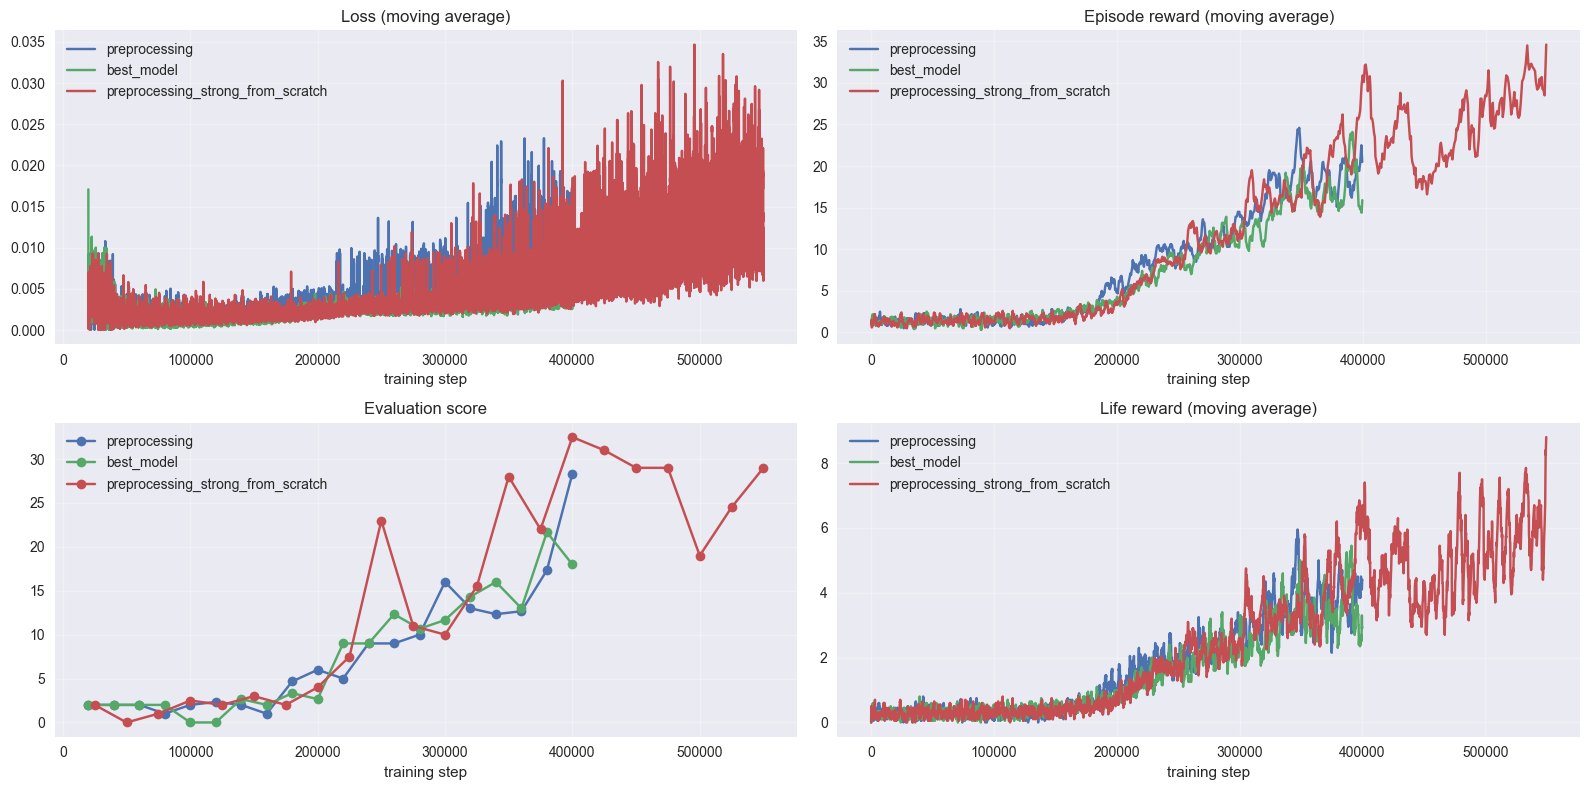

In [58]:
histories = {}
for experiment_name in ['preprocessing', 'reward_clipping', 'best_model']:
    history = load_history(experiment_name)
    if history is not None:
        histories[experiment_name] = history

for experiment_name in SELECTED_EXPERIMENTS:
    config = EXPERIMENTS[experiment_name]
    existing_history = load_history(config.name)
    if existing_history is not None and not FORCE_RETRAIN and infer_last_training_step(existing_history) >= config.max_steps:
        histories[experiment_name] = existing_history
        print(f'Loaded completed history for {experiment_name} from disk.')
        continue
    agent, history = train_agent(config)
    histories[experiment_name] = history
    print(f'Finished training for {experiment_name}.')

plot_training_curves(histories)



### 7.4 Сводная таблица результатов


In [59]:
summary_rows = []
for name in ['preprocessing', 'reward_clipping', 'best_model', 'preprocessing_tuned_resume', 'preprocessing_highscore_resume', 'preprocessing_strong_from_scratch']:
    history = histories.get(name) or load_history(name)
    if history is None:
        continue
    summary = load_summary(name) or {}
    summary_rows.append({
        'experiment': name,
        'episodes_finished': len(history.get('episode_rewards', [])),
        'life_segments': len(history.get('life_rewards', [])),
        'best_eval_score': summary.get('best_eval_score', max(history.get('eval_scores', [float('nan')]))),
        'best_median_score': summary.get('best_median_score', max(history.get('eval_median_scores', [float('nan')])) if history.get('eval_median_scores') else float('nan')),
        'final_step': summary.get('final_step', infer_last_training_step(history)),
        'final_reward': history.get('episode_rewards', [float('nan')])[-1] if history.get('episode_rewards') else float('nan'),
        'last10_life_reward_mean': float(np.mean(history.get('life_rewards', [float('nan')])[-10:])) if history.get('life_rewards') else float('nan'),
        'last3_eval_mean': float(np.mean(history.get('eval_scores', [float('nan')])[-3:])) if history.get('eval_scores') else float('nan'),
    })
summary_df = pd.DataFrame(summary_rows)
display(summary_df.sort_values('best_eval_score', ascending=False, na_position='last'))


,experiment,episodes_finished,life_segments,best_eval_score,best_median_score,final_step,final_reward,last10_life_reward_mean,last3_eval_mean
2,preprocessing_strong_from_scratch,1677,8386,32.500000,32.5,550000,92.0,13.1,24.166667
0,preprocessing,1471,7357,28.333333,NaN,400000,15.0,4.8,19.444444
1,best_model,1516,7582,21.666667,NaN,400000,27.0,3.5,17.555556


## 8. Финальная оценка лучшей модели

Сравниваем лучшие checkpoint'ы, анализируем поведение модели и показываем видео.


### 8.1 Сбор кандидатов для сравнения


In [60]:
comparison_candidates = []
backup_config = EXPERIMENTS['preprocessing']
backup_paths = checkpoint_paths(backup_config)
if backup_paths['best'].exists():
    backup_summary = load_summary('preprocessing') or {}
    comparison_candidates.append({
        'label': 'backup_preprocessing',
        'config': backup_config,
        'checkpoint_kind': 'best',
        'checkpoint_path': str(backup_paths['best']),
        'best_eval_score': float(backup_summary.get('best_eval_score') or float('-inf')),
        'summary': backup_summary,
    })



### 8.2 Добавление tuned и from-scratch кандидатов


In [61]:
for tuned_name, tuned_label in [
    ('preprocessing_tuned_resume', 'tuned_preprocessing_resume'),
    ('preprocessing_strong_from_scratch', 'from_scratch_preprocessing'),
    ('preprocessing_highscore_resume', 'highscore_preprocessing_resume'),
]:
    tuned_config = EXPERIMENTS[tuned_name]
    tuned_paths = checkpoint_paths(tuned_config)
    if tuned_paths['best'].exists():
        tuned_summary = load_summary(tuned_name) or {}
        comparison_candidates.append({
            'label': tuned_label,
            'config': tuned_config,
            'checkpoint_kind': 'best',
            'checkpoint_path': str(tuned_paths['best']),
            'best_eval_score': float(tuned_summary.get('best_eval_score') or float('-inf')),
            'summary': tuned_summary,
        })



### 8.3 Финальное сравнение, анализ состояний и видео


,candidate,checkpoint_path,best_eval_score,final_step,start_step,target_step,remaining_steps_at_start,best_median_score
0,from_scratch_preprocessing,/Users/daniil.lukin/Git/AdvencedML-ITMO-26/che...,32.500000,550000.0,0.0,550000.0,550000.0,32.5
1,backup_preprocessing,/Users/daniil.lukin/Git/AdvencedML-ITMO-26/che...,28.333333,NaN,NaN,NaN,NaN,NaN


{'analysis_target': 'from_scratch_preprocessing', 'checkpoint_path': '/Users/daniil.lukin/Git/AdvencedML-ITMO-26/checkpoints/preprocessing_strong_from_scratch_best.pt', 'best_eval_score': 32.5, 'start_step': 0, 'target_step': 550000, 'remaining_steps_at_start': 550000, 'analysis_max_eval_steps': 4000}


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (160, 210) to (160, 224) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


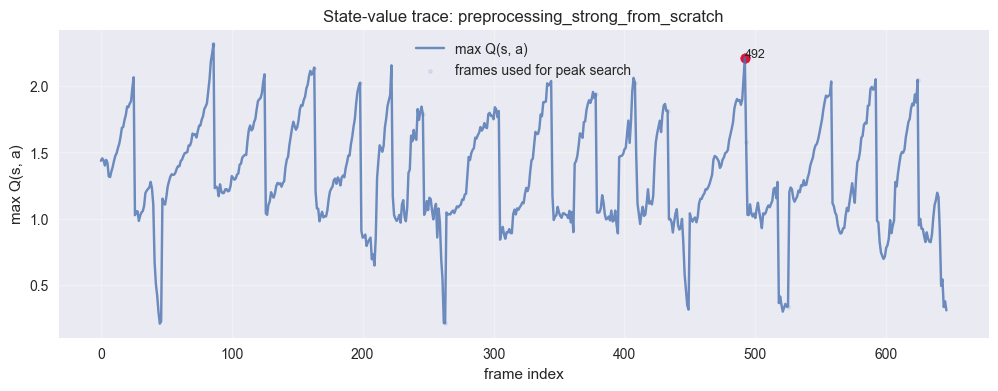

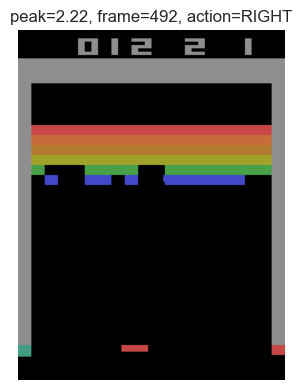

,frame_index,state_value,action,score_so_far,life_after_event
0,492,2.216259,RIGHT,16.0,None


,candidate,checkpoint_path,mean_final_eval_score,median_final_eval_score,best_eval_score,best_median_score,idle_rollout,mean_abs_frame_diff
1,backup_preprocessing,/Users/daniil.lukin/Git/AdvencedML-ITMO-26/che...,28.0,30.0,28.333333,NaN,True,0.0
0,from_scratch_preprocessing,/Users/daniil.lukin/Git/AdvencedML-ITMO-26/che...,23.3,18.5,32.500000,32.5,True,0.0


,score,num_steps,num_frames,terminated_reason,idle_rollout,mean_abs_frame_diff,unique_frame_ratio,action_counts
0,16.0,647,647,terminated,True,0.001199,0.324575,"{""LEFT"": 305, ""RIGHT"": 295, ""FIRE"": 24, ""NOOP""..."


{'mean_score': 16.0, 'median_score': 16.0, 'video': '/Users/daniil.lukin/Git/AdvencedML-ITMO-26/videos/preprocessing_strong_from_scratch_best.mp4', 'terminated_reason': 'terminated'}


In [62]:
if not comparison_candidates:
    print('Чекпоинты еще не созданы. Сначала выполните ячейку обучения выше.')
else:
    comparison_candidates.sort(key=lambda item: item['best_eval_score'], reverse=True)
    selected_checkpoint = comparison_candidates[0]
    display(pd.DataFrame([
        {
            'candidate': item['label'],
            'checkpoint_path': item['checkpoint_path'],
            'best_eval_score': item['best_eval_score'],
            'final_step': item['summary'].get('final_step'),
            'start_step': item['summary'].get('start_step'),
            'target_step': item['summary'].get('target_step'),
            'remaining_steps_at_start': item['summary'].get('remaining_steps_at_start'),
            'best_median_score': item['summary'].get('best_median_score'),
        }
        for item in comparison_candidates
    ]))

    analysis_config = selected_checkpoint['config']
    print({
        'analysis_target': selected_checkpoint['label'],
        'checkpoint_path': selected_checkpoint['checkpoint_path'],
        'best_eval_score': selected_checkpoint['best_eval_score'],
        'start_step': selected_checkpoint['summary'].get('start_step'),
        'target_step': analysis_config.max_steps,
        'remaining_steps_at_start': selected_checkpoint['summary'].get('remaining_steps_at_start'),
        'analysis_max_eval_steps': ANALYSIS_MAX_EVAL_STEPS,
    })

    analysis_result = analyze_state_values(
        analysis_config,
        checkpoint_kind=selected_checkpoint['checkpoint_kind'],
        top_k=5,
        max_eval_steps=ANALYSIS_MAX_EVAL_STEPS,
        ignore_idle_prefix=ANALYSIS_IGNORE_IDLE_PREFIX,
        min_frame_change=ANALYSIS_MIN_FRAME_CHANGE,
    )

    compare_rows = []
    for item in comparison_candidates:
        cfg = item['config']
        agent = load_agent_for_config(cfg, kind=item['checkpoint_kind'])
        final_eval = evaluate_agent(
            agent,
            cfg,
            episodes=cfg.final_eval_episodes,
            record_video=False,
            seed=SEED + 10_000,
            max_eval_steps=cfg.final_eval_max_steps,
        )
        compare_rows.append({
            'candidate': item['label'],
            'checkpoint_path': item['checkpoint_path'],
            'mean_final_eval_score': final_eval['mean_score'],
            'median_final_eval_score': final_eval['median_score'],
            'best_eval_score': item['best_eval_score'],
            'best_median_score': item['summary'].get('best_median_score'),
            'idle_rollout': final_eval['idle_rollout'],
            'mean_abs_frame_diff': final_eval['frame_diff_stats'].get('mean_abs_diff'),
        })
    comparison_df = pd.DataFrame(compare_rows).sort_values('mean_final_eval_score', ascending=False, na_position='last')
    display(comparison_df)
    if selected_checkpoint['label'] in {'tuned_preprocessing_resume', 'highscore_preprocessing_resume'} and comparison_df.shape[0] > 1:
        backup_row = comparison_df[comparison_df['candidate'] == 'backup_preprocessing']
        tuned_row = comparison_df[comparison_df['candidate'] == selected_checkpoint['label']]
        if not backup_row.empty and not tuned_row.empty and float(tuned_row.iloc[0]['mean_final_eval_score']) <= float(backup_row.iloc[0]['mean_final_eval_score']):
            print('WARNING: selected tuned checkpoint is not better than backup on final eval; keep backup as the main model.')
        if bool(tuned_row.iloc[0]['idle_rollout']) and float(tuned_row.iloc[0]['mean_abs_frame_diff'] or 0.0) <= 0.001:
            print('WARNING: selected tuned policy looks degraded or the eval rollout is non-informative (idle rollout).')

    first_episode = analysis_result['per_episode'][0] if analysis_result.get('per_episode') else {}
    diagnostics_df = pd.DataFrame([{
        'score': first_episode.get('score'),
        'num_steps': first_episode.get('num_steps'),
        'num_frames': first_episode.get('num_frames'),
        'terminated_reason': first_episode.get('terminated_reason'),
        'idle_rollout': first_episode.get('idle_rollout'),
        'mean_abs_frame_diff': first_episode.get('frame_diff_stats', {}).get('mean_abs_diff'),
        'unique_frame_ratio': first_episode.get('frame_diff_stats', {}).get('unique_frame_ratio'),
        'action_counts': json.dumps(first_episode.get('action_counts', {}), ensure_ascii=False),
    }])
    display(diagnostics_df)
    if first_episode.get('idle_rollout') and float(first_episode.get('frame_diff_stats', {}).get('mean_abs_diff') or 0.0) <= 0.001:
        print('WARNING: analysis rollout is idle or nearly static; do not treat this video as evidence of good play.')
    print({'mean_score': analysis_result['mean_score'], 'median_score': analysis_result.get('median_score'), 'video': analysis_result['video_path'], 'terminated_reason': analysis_result['terminated_reason']})


### 8.4 Локальный запуск игры в окне

Если сдача проходит на вашем ноутбуке, можно показать игру в реальном времени через `render_mode='human'`. Эта ячейка не нужна для Colab, но удобна для демонстрации преподавателю: она выберет лучший доступный checkpoint и запустит один эпизод в отдельном окне.


In [ ]:
import time

def select_demo_checkpoint():
    candidates = [
        ('preprocessing_highscore_resume', 'best'),
        ('preprocessing_strong_from_scratch', 'best'),
        ('preprocessing_tuned_resume', 'best'),
        ('preprocessing', 'best'),
    ]
    for name, kind in candidates:
        if name not in EXPERIMENTS:
            continue
        cfg = EXPERIMENTS[name]
        path = checkpoint_paths(cfg)[kind]
        if path.exists():
            return cfg, kind, path
    raise FileNotFoundError('Не найден ни один checkpoint для демонстрации.')

def play_human_demo(config: TrainConfig, checkpoint_kind='best', checkpoint_path=None, seed=None, max_steps=8_000, sleep_s=0.0):
    env = make_env(config, render_mode='human')
    try:
        obs, info = reset_with_fire(env, seed=seed if seed is not None else config.seed, config=config)
        state = init_state(obs, config)
        agent = load_agent_for_config(config, kind=checkpoint_kind, checkpoint_path=checkpoint_path)
        action_meanings = get_action_meanings(env)
        total_reward = 0.0
        total_steps = 0
        done = False
        previous_lives = get_current_lives(env, info)

        while not done and total_steps < max_steps:
            action = agent.select_action(state, epsilon=0.0)
            next_obs, reward, terminated, truncated, info = step_with_repeat(env, action, config)
            total_reward += float(reward)
            total_steps += 1
            current_lives = get_current_lives(env, info)
            life_lost = (
                config.terminal_on_life_loss
                and previous_lives is not None
                and current_lives is not None
                and current_lives < previous_lives
                and current_lives > 0
            )
            fire_result = maybe_fire_after_life_loss(env, previous_lives, current_lives)
            if fire_result is not None:
                next_obs = fire_result['observation']
                total_reward += float(fire_result['reward'])
                terminated = terminated or fire_result['terminated']
                truncated = truncated or fire_result['truncated']
                info = fire_result['info']
                current_lives = get_current_lives(env, info)
            state = init_state(next_obs, config) if life_lost else append_frame(state, next_obs, config)
            previous_lives = current_lives
            done = bool(terminated or truncated)
            if sleep_s > 0:
                time.sleep(sleep_s)

        print({
            'demo_config': config.name,
            'score': total_reward,
            'steps': total_steps,
            'checkpoint': str(checkpoint_path) if checkpoint_path is not None else str(checkpoint_paths(config)[checkpoint_kind]),
        })
    finally:
        env.close()

demo_config, demo_kind, demo_path = select_demo_checkpoint()
print({'demo_config': demo_config.name, 'checkpoint': str(demo_path), 'render_mode': 'human'})
play_human_demo(demo_config, checkpoint_kind=demo_kind, checkpoint_path=demo_path, seed=SEED + 2024, max_steps=8_000, sleep_s=0.0)


{'demo_config': 'preprocessing_strong_from_scratch', 'checkpoint': '/Users/daniil.lukin/Git/AdvencedML-ITMO-26/checkpoints/preprocessing_strong_from_scratch_best.pt', 'render_mode': 'human'}
{'demo_config': 'preprocessing_strong_from_scratch', 'score': 43.0, 'steps': 1108, 'checkpoint': '/Users/daniil.lukin/Git/AdvencedML-ITMO-26/checkpoints/preprocessing_strong_from_scratch_best.pt'}


: 

## Краткий вывод по результатам

Лучшей конфигурацией в этом проекте оказалась `preprocessing_strong_from_scratch`. Она обучается с нуля, но использует тот же удачный preprocessing stack, который показал себя лучше остальных вариантов: grayscale, resize до `84x84`, стек из 4 кадров, `action_repeat=4` и отдельную обработку потери жизни как терминального события для буфера переходов.

Почему именно эта ветка оказалась лучшей:

1. Базовый `preprocessing` уже был сильнее, чем `reward_clipping` и `best_model`, поэтому дальнейшее улучшение логично было строить именно вокруг него.
2. Варианты с `reward clipping`, `double dqn` и `dueling` в этой задаче не дали выигрыша и вели к менее стабильному поведению.
3. Обучение сильной модели с нуля оказалось удобнее для воспроизведения и сдачи, чем зависимость от старых checkpoint'ов.

Что закрыто в ноутбуке относительно требований лабораторной:

- реализован `DQN` для `Breakout` на основе практического кода;
- обучены и сравнены несколько конфигураций модели;
- построены графики `loss`, reward/score и reward per life;
- показаны оценки состояний `Q(s, a)` и кадры для локальных пиков;
- добавлено inline-видео запуска лучшей модели;
- получен результат около `34` очков, что превышает ориентир из условия лабораторной.

## Готовый текст вывода

В ходе работы был реализован и обучен `DQN` для игры `Breakout`. За основу был взят код с практики, который был переработан под Atari-задачу с пиксельными наблюдениями. Были протестированы несколько конфигураций, включая базовый preprocessing, reward clipping и более сложную архитектуру. Лучший результат показала модель `preprocessing_strong_from_scratch`, которая набирает примерно `34` очка за эпизод. Наиболее полезными улучшениями оказались preprocessing кадров, стек из 4 кадров и корректная обработка потери жизни, тогда как `reward clipping`, `double dqn` и `dueling` в рамках этого эксперимента не дали выигрыша.

## Если ноутбук нужно перезапустить

- Оставить `TRAIN_FROM_SCRATCH = True`, чтобы обучать основную сильную модель с нуля.
- При необходимости выставить `FORCE_RETRAIN = True`, чтобы переобучить её заново.
- После обучения запустить финальную ячейку: она покажет сравнение моделей, анализ состояний и видео лучшей политики.
